#### Get dataset from Kaggle

In [5]:
# uncomment to download
!curl -L -o e-commerce-fraud-detection-dataset.zip https://www.kaggle.com/api/v1/datasets/download/umuttuygurr/e-commerce-fraud-detection-dataset
!unzip e-commerce-fraud-detection-dataset.zip -d data
!rm e-commerce-fraud-detection-dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6102k  100 6102k    0     0  4903k      0  0:00:01  0:00:01 --:--:-- 22.9M
Archive:  e-commerce-fraud-detection-dataset.zip
  inflating: data/transactions.csv   


#### Helper functions

In [2]:
def load_csv_data(csv_data_file, verbose=True):
    df = pd.read_csv(csv_data_file,
                     low_memory=False
    )
    if verbose:
        print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df

def plot_target_distribution(df, target_col):
    # Visualize target variable distribution
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    
    # Count plot
    df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
    axes[0].set_title(f'Target Variable ({target_col}) Distribution', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Regular (0)', 'Fraud (1)'], rotation=0)
    
    # Percentage plot
    df[target_col].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
    axes[1].set_title(f'Target Variable ({target_col}) Distribution in %', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Percentage')
    axes[1].set_xticklabels(['Regular (0)', 'Fraud (1)'], rotation=0)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    plt.tight_layout()
    plt.show()

def plot_box_plots(df, numeric_features, target_col):
    """Compare feature distributions between fraud and normal transactions using box plots."""
    fig, axes = plt.subplots(3, 2, figsize=(15, 13))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_features):
        ax = axes[idx]
        df.boxplot(column=col, by=target_col, ax=ax, patch_artist=True)
        ax.set_title(f'{col} by Fraud Status', fontsize=11, fontweight='bold')
        ax.set_xlabel('Is Fraud')
        ax.set_ylabel(col)
        ax.set_xticklabels(['Normal', 'Fraud'])
        plt.sca(ax)
        plt.xticks([1, 2], ['Normal (0)', 'Fraud (1)'])
    
    if len(numeric_features) < len(axes):
        fig.delaxes(axes[-1])
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
    
    print("\nBox Plot Interpretation:")
    print("* Look for differences in medians (center line) between fraud and normal")
    print("* Different distributions suggest the feature is discriminative")
    print("* Overlapping boxes indicate less predictive power")

def analyze_categorical_features(df, categorical_features, target_col):
    """Analyze fraud rates for each categorical feature."""
    print("Fraud Rates by Categorical Features")
    print("=" * 80)
    
    for feature in categorical_features:
        print(f"\n{feature.upper()}:")
        print("-" * 80)
        
        fraud_rate = df.groupby(feature)[target_col].agg(['sum', 'count', 'mean']).reset_index()
        fraud_rate.columns = [feature, 'fraud_count', 'total_count', 'fraud_rate']
        fraud_rate['fraud_rate'] = fraud_rate['fraud_rate'] * 100
        fraud_rate = fraud_rate.sort_values('fraud_rate', ascending=False)
        
        print(fraud_rate.to_string(index=False))
        
        baseline_rate = df[target_col].mean() * 100
        high_risk = fraud_rate[fraud_rate['fraud_rate'] > baseline_rate * 1.5]
        if not high_risk.empty:
            print(f"\n⚠️  High-risk categories (>1.5x baseline rate of {baseline_rate:.2f}%):")
            for _, row in high_risk.iterrows():
                print(f"   - {row[feature]}: {row['fraud_rate']:.2f}% fraud rate")
    
    print("\n" + "=" * 80)

def download_data_csv(kaggle_source, data_dir, csv_file):
    """Download csv file from kaggle_source. Requires install of kaggle python
    package to use the Kaggle API and Kaggle API credentials set up in
    `~/.kaggle/kaggle.json`. Creates data directory, data_dir, if it doesn't
    exist. csv_file is the name of the downloaded file.
    """
    Path(data_dir).mkdir(parents=True, exist_ok=True)
    if not os.path.exists(f"{data_dir}/{csv_file}"):
        print(f"\nDownloading dataset from Kaggle...")
        !kaggle datasets download -d {kaggle_source} -p {data_dir} --unzip
        print("Download complete!")
    else:
        print(f"\nDataset already exists at {data_dir}/{csv_file}")

def load_data(data_dir, csv_file, verbose=True):
    df = pd.read_csv(
        f"{data_dir}/{csv_file}",
        low_memory=False  # Read entire file to infer dtypes properly
    )
    if verbose:
        print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"\nMemory Usage:\n{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df
    
def plot_target_distribution(df, target_col):
    # Visualize target variable distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Count plot
    df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
    axes[0].set_title('Target Variable Distribution (Count)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Is Fraud')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
    
    # Percentage plot
    df[target_col].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
    axes[1].set_title('Target Variable Distribution (Percentage)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Is Fraud')
    axes[1].set_ylabel('Percentage')
    axes[1].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    plt.tight_layout()
    plt.show()
    
def analyze_target_stats(df, target_col):
    # Target distribution
    target_dist = df[target_col].value_counts(normalize=True)
    print("\nTarget Distribution (%):")
    print(target_dist * 100)
    # Check class imbalance
    target_vals = target_dist.values
    target_ratio = target_vals[0] / target_vals[1]
    if target_ratio > 10:
        print(f"\n{BOLD}Warning: Large class imbalance ({target_ratio:.1f}) detected!\n")
    else:
        print(f"\nClass imbalance = {target_ratio:.1f}\n")
    plot_target_distribution(df, target_col)

def analyze_feature_stats(df, id_cols, target_col, categorical_features, numeric_features):
    # Summary for categorical/object columns
    print(f"\nCategorical Features ({len(categorical_features)}): {categorical_features}")
    if len(categorical_features) > 0:
        print("\nCategorical Features Summary:")
        for col in categorical_features:
            print(f"\n{col}:")
            print(f"  Unique values: {df[col].nunique()}")
            print(f"  Top 5 values:\n{df[col].value_counts().head()}")

    # Statistical summary for numerical columns
    print(f"\n\nNumeric Features ({len(numeric_features)}): {numeric_features}")
    print("\nNumeric Features Summary:")
    display(df[numeric_features].describe())
        
def split_train_val_test(df, val_ratio=.2, test_ratio=.2, stratify=None, r_seed=1, verbose=False):
    """Use the train_test_split function from sklearn to split input dataframe
    into randomly shuffled train, validation, and test datasets. Stratify, if provided, gives 
    the column name to use when stratifying the splits.
    """
    n = len(df)
    # Generate test dataset
    strat_col = stratify
    if stratify:
        strat_col = df[stratify]
    full_train_df, test_df = train_test_split(df, test_size=test_ratio, stratify=strat_col, random_state=r_seed)
    test_df = test_df.reset_index(drop=True)
    # Generate train, validation, and test splits
    val_ft_ratio = val_ratio / (1 - test_ratio)
    if stratify:
        strat_col = full_train_df[stratify]
    train_df, val_df = train_test_split(full_train_df, test_size=val_ft_ratio, stratify=strat_col, random_state=r_seed)
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    if verbose:
        print(f"All rows in the original dataframe are contained within the training, validation, or test datasets: {len(train_df) + len(val_df) + len(test_df) == len(df)}")
        print(f"\nTrain set: {len(train_df)} rows ({len(train_df)/len(df)*100:.1f}%)")
        print(f"Validation set: {len(val_df)} rows ({len(val_df)/len(df)*100:.1f}%)")
        print(f"Test set: {len(test_df)} rows ({len(test_df)/len(df)*100:.1f}%)")
    return train_df, val_df, test_df

#### Feature engineering

In [3]:
def get_country_timezone_mapping():
    """Create mapping of country codes to capital city timezones."""
    return {
        'US': 'America/New_York',       # Washington D.C.
        'GB': 'Europe/London',          # London
        'FR': 'Europe/Paris',           # Paris
        'DE': 'Europe/Berlin',          # Berlin
        'IT': 'Europe/Rome',            # Rome
        'ES': 'Europe/Madrid',          # Madrid
        'NL': 'Europe/Amsterdam',       # Amsterdam
        'PL': 'Europe/Warsaw',          # Warsaw
        'RO': 'Europe/Bucharest',       # Bucharest
        'TR': 'Europe/Istanbul'         # Istanbul
    }

def convert_utc_to_local_time(df, date_col, country_col):
    """
    Convert UTC timestamps to local time based on country's capital timezone.
    Returns DataFrame with additional local_time column.

    Requires:
        - date_col must be timezone-aware datetime in UTC
        - Will raise ValueError if timezone is missing or not UTC
    """
    df = df.copy()
    tz_mapping = get_country_timezone_mapping()
    
    # Initialize local_time column (timezone-naive, will represent local times)
    df['local_time'] = df[date_col].dt.tz_localize(None)
    
    print("Converting UTC to local time by country...")
    for country, tz_str in tz_mapping.items():
        mask = df[country_col] == country
        if mask.sum() > 0:
            # Convert UTC to local timezone
            # Get the datetime series
            dt_series = df.loc[mask, date_col]

            # Validate that input is timezone-aware and in UTC
            if dt_series.dt.tz is None:
                raise ValueError(
                    f"Column '{date_col}' must be timezone-aware in UTC. "
                    f"Ensure timestamps are parsed with utc=True during data loading."
                )

            # Validate it's in UTC
            if str(dt_series.dt.tz) != 'UTC':
                raise ValueError(
                    f"Column '{date_col}' must be in UTC timezone, "
                    f"but found: {dt_series.dt.tz}"
                )

            # Convert UTC to target local timezone
            utc_times = dt_series
            local_times = utc_times.dt.tz_convert(tz_str).dt.tz_localize(None)
            df.loc[mask, 'local_time'] = local_times
    
    print(f"  ✓ Converted {len(df)} transactions to local time")
    return df

def create_temporal_features(df, date_col, use_local_time=False):
    """
    Create time features from timestamp column.
    """
    df = df.copy()
    time_col = 'local_time' if use_local_time else date_col
    suffix = '_local' if use_local_time else ''
    
    # Extract basic time components
    df[f'hour{suffix}'] = df[time_col].dt.hour
    df[f'day_of_week{suffix}'] = df[time_col].dt.dayofweek  # 0=Monday, 6=Sunday
    df[f'month{suffix}'] = df[time_col].dt.month
    
    # Derived temporal features
    df[f'is_weekend{suffix}'] = (df[f'day_of_week{suffix}'] >= 5).astype(int)
    df[f'is_late_night{suffix}'] = ((df[f'hour{suffix}'] >= 23) | (df[f'hour{suffix}'] <= 4)).astype(int)
    df[f'is_business_hours{suffix}'] = ((df[f'hour{suffix}'] >= 9) & (df[f'hour{suffix}'] <= 17)).astype(int)
    
    features_created = [f'hour{suffix}', f'day_of_week{suffix}', f'month{suffix}',
                       f'is_weekend{suffix}', f'is_late_night{suffix}', f'is_business_hours{suffix}']
    
    return df, features_created

def create_extra_features(df):
    df = df.copy()
    
    # Amount deviation from user's average
    df['amount_deviation'] = (df['amount'] - df['avg_amount_user']).abs()
    
    # Amount ratio compared to user's average (handle division by zero)
    df['amount_vs_avg_ratio'] = df['amount'] / df['avg_amount_user'].replace(0, 1)
    
    # Micro transactions (potential card testing)
    df['is_micro_transaction'] = (df['amount'] <= 5).astype(int)
    
    # Large transactions
    df['is_large_transaction'] = (df['amount'] >= df['amount'].quantile(0.95)).astype(int)

    df['is_new_account'] = (df['account_age_days'] <= 30).astype(int)
    
    # High frequency user
    df['is_high_frequency_user'] = (df['total_transactions_user'] >= df['total_transactions_user'].quantile(0.75)).astype(int)

    # Country mismatch (user country != card issuing country)
    df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)
    
    # High risk shipping distance (>80th percentile)
    distance_threshold = df['shipping_distance_km'].quantile(0.8)

    df['high_risk_distance'] = (df['shipping_distance_km'] > distance_threshold).astype(int)

    # Security score (count of passed verifications)
    df['security_score'] = df['avs_match'] + df['cvv_result'] + df['three_ds_flag']
    
    # Count of failed verifications
    df['verification_failures'] = 3 - df['security_score']
    
    # All verifications passed
    df['all_verifications_passed'] = (df['security_score'] == 3).astype(int)
    
    # All verifications failed (high risk)
    df['all_verifications_failed'] = (df['security_score'] == 0).astype(int)
    features = ['amount_deviation', 'amount_vs_avg_ratio', 'is_micro_transaction', 'is_large_transaction', 
                'is_new_account', 'is_high_frequency_user', 'country_mismatch', 'high_risk_distance', 
                'security_score', 'verification_failures', 'all_verifications_passed', 'all_verifications_failed']

    return df, features

In [66]:
import pandas as pd
import numpy as np
import json
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt

import joblib

import xgboost as xgb

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)


In [5]:
df = load_csv_data('data/transactions.csv')


Dataset Shape: 299695 rows, 17 columns
Memory Usage: 107.29 MB


In [6]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,299685,299686,299687,299688,299689,299690,299691,299692,299693,299694
transaction_id,1,2,3,4,5,6,7,8,9,10,...,299686,299687,299688,299689,299690,299691,299692,299693,299694,299695
user_id,1,1,1,1,1,1,1,1,1,1,...,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
account_age_days,141,141,141,141,141,141,141,141,141,141,...,996,996,996,996,996,996,996,996,996,996
total_transactions_user,47,47,47,47,47,47,47,47,47,47,...,45,45,45,45,45,45,45,45,45,45
avg_amount_user,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,...,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93
amount,84.75,107.9,92.36,112.47,132.91,224.82,125.98,66.95,261.58,97.34,...,14.77,22.82,33.97,22.42,100.16,34.07,68.56,25.02,23.92,26.07
country,FR,FR,FR,FR,FR,FR,FR,FR,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
bin_country,FR,FR,FR,FR,US,FR,FR,RO,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
channel,web,web,app,web,web,web,app,web,app,web,...,web,web,app,web,app,web,app,app,web,web
merchant_category,travel,travel,travel,fashion,electronics,travel,electronics,travel,grocery,electronics,...,gaming,fashion,electronics,electronics,travel,grocery,travel,fashion,gaming,gaming


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

#### Define feature types

In [8]:
target_col = "is_fraud"
id_cols = ['transaction_id', 'user_id']
datetime_col = 'transaction_time'
# categorical
categorical_feats = ['country', 'bin_country', 'channel', 'merchant_category', 
                       'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']
# numeric
numeric_feats = ['account_age_days', 'total_transactions_user', 'avg_amount_user', 
                   'amount', 'shipping_distance_km']

# dir for models selection playground
model_dir = "models" 

In [9]:
# convert to datetime
df[datetime_col] = pd.to_datetime(df[datetime_col], utc=True, errors='coerce')

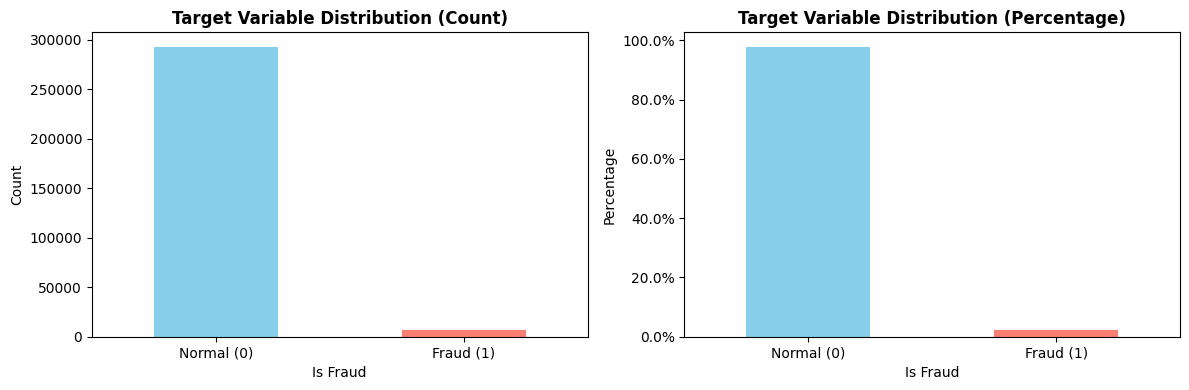

In [10]:
plot_target_distribution(df, target_col)

In [11]:
target_dist = df[target_col].value_counts()
print(f'Target class imbalance (#regular/#fraud): {target_dist[0]/target_dist[1]}')

Target class imbalance (#regular/#fraud): 44.325922565033274


#### Numeric features

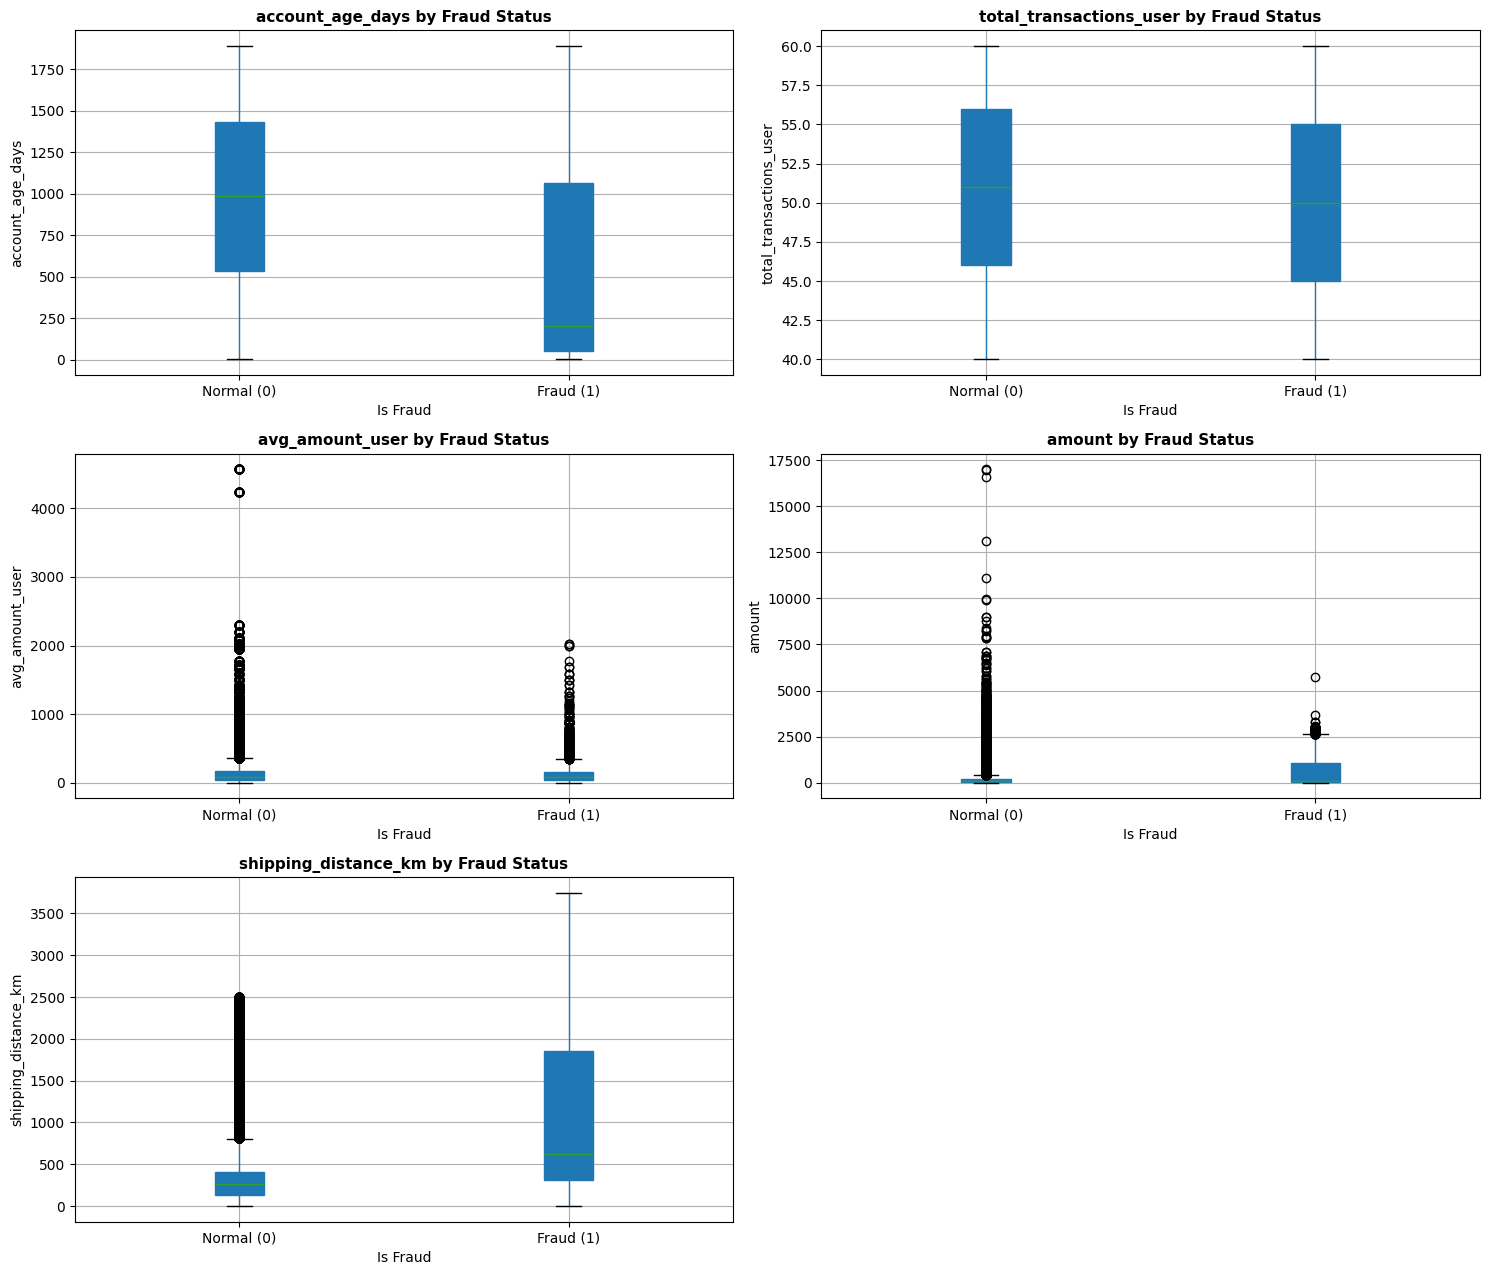


Box Plot Interpretation:
* Look for differences in medians (center line) between fraud and normal
* Different distributions suggest the feature is discriminative
* Overlapping boxes indicate less predictive power


In [12]:
plot_box_plots(df, numeric_feats, target_col)

#### Categorical features

In [13]:
analyze_categorical_features(df, categorical_feats, target_col)

Fraud Rates by Categorical Features

COUNTRY:
--------------------------------------------------------------------------------
country  fraud_count  total_count  fraud_rate
     TR          843        30074    2.803086
     RO          709        29501    2.403308
     PL          701        29965    2.339396
     ES          668        28885    2.312619
     US          748        32430    2.306506
     FR          664        30343    2.188314
     IT          607        28615    2.121265
     GB          648        30602    2.117509
     NL          539        30220    1.783587
     DE          485        29060    1.668961

BIN_COUNTRY:
--------------------------------------------------------------------------------
bin_country  fraud_count  total_count  fraud_rate
         TR          781        29972    2.605765
         PL          699        29963    2.332877
         RO          679        29532    2.299201
         ES          666        29058    2.291968
         IT          6

#### Create features based on transaction times

In [35]:
df_time = convert_utc_to_local_time(df, datetime_col, 'country')

df_time, local_features = create_temporal_features(df_time, datetime_col, use_local_time=True)
print(f" ✓ Created {len(local_features)} local time features")
print(local_features)

Converting UTC to local time by country...
  ✓ Converted 299695 transactions to local time
 ✓ Created 6 local time features
['hour_local', 'day_of_week_local', 'month_local', 'is_weekend_local', 'is_late_night_local', 'is_business_hours_local']


#### Create extra features based on base features 

In [36]:
df_eng, extra_features = create_extra_features(df_time)
print(f" ✓ Created {len(extra_features)} extra features: {extra_features}")

 ✓ Created 12 extra features: ['amount_deviation', 'amount_vs_avg_ratio', 'is_micro_transaction', 'is_large_transaction', 'is_new_account', 'is_high_frequency_user', 'country_mismatch', 'high_risk_distance', 'security_score', 'verification_failures', 'all_verifications_passed', 'all_verifications_failed']


In [16]:
df_eng.T

,0,1,2,3,4,5,6,7,8,9,...,299685,299686,299687,299688,299689,299690,299691,299692,299693,299694
transaction_id,1,2,3,4,5,6,7,8,9,10,...,299686,299687,299688,299689,299690,299691,299692,299693,299694,299695
user_id,1,1,1,1,1,1,1,1,1,1,...,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
account_age_days,141,141,141,141,141,141,141,141,141,141,...,996,996,996,996,996,996,996,996,996,996
total_transactions_user,47,47,47,47,47,47,47,47,47,47,...,45,45,45,45,45,45,45,45,45,45
avg_amount_user,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,...,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93
amount,84.75,107.9,92.36,112.47,132.91,224.82,125.98,66.95,261.58,97.34,...,14.77,22.82,33.97,22.42,100.16,34.07,68.56,25.02,23.92,26.07
country,FR,FR,FR,FR,FR,FR,FR,FR,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
bin_country,FR,FR,FR,FR,US,FR,FR,RO,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
channel,web,web,app,web,web,web,app,web,app,web,...,web,web,app,web,app,web,app,app,web,web
merchant_category,travel,travel,travel,fashion,electronics,travel,electronics,travel,grocery,electronics,...,gaming,fashion,electronics,electronics,travel,grocery,travel,fashion,gaming,gaming


#### Feature exclusion

In [18]:
exclude_cols = id_cols + ['country', 'bin_country', 'merchant_category', 'transaction_time', 'local_time', 
                          'verification_failures', 'all_verifications_passed', 'all_verifications_failed']

#### Train, validation and test datasets

In [39]:
train_df, val_df, test_df = split_train_val_test(df_eng.drop(exclude_cols, axis=1), val_ratio=0.2, test_ratio=0.2, stratify=target_col, verbose=True)

All rows in the original dataframe are contained within the training, validation, or test datasets: True

Train set: 179817 rows (60.0%)
Validation set: 59939 rows (20.0%)
Test set: 59939 rows (20.0%)


In [26]:
# Separate target from features
feature_cols = [col for col in train_df.columns if col != target_col]

# Identify numeric vs categorical features
numeric_features = train_df[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train_df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

# For binary features that might be stored as int, we may want to treat them as categorical
# Check for binary features in numeric columns
binary_features = []
for col in numeric_features:
    unique_vals = train_df[col].nunique()
    if unique_vals == 2:
        binary_features.append(col)

print(f"Feature breakdown:")
print(f"  • Total features: {len(feature_cols)}")
print(f"  • Numeric features: {len(numeric_features)}")
print(f"  • Categorical features: {len(categorical_features)}")
print(f"  • Binary features (int encoded): {len(binary_features)}")

print(f"\nNumeric features ({len(numeric_features)}):")
print(f"  {numeric_features}")

print(f"\nCategorical features ({len(categorical_features)}):")
print(f"  {categorical_features}")

if binary_features:
    print(f"\nBinary features ({len(binary_features)}):")
    print(f"  {binary_features}")

Feature breakdown:
  • Total features: 13
  • Numeric features: 12
  • Categorical features: 1
  • Binary features (int encoded): 6

Numeric features (12):
  ['account_age_days', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'three_ds_flag', 'shipping_distance_km', 'amount_deviation', 'amount_vs_avg_ratio', 'is_micro_transaction', 'is_large_transaction', 'country_mismatch']

Categorical features (1):
  ['channel']

Binary features (6):
  ['promo_used', 'avs_match', 'three_ds_flag', 'is_micro_transaction', 'is_large_transaction', 'country_mismatch']


In [27]:
# Continuous numeric (need scaling for Logistic Regression)
continuous_numeric = [
    'account_age_days', 'total_transactions_user', 'avg_amount_user', 
    'amount', 'shipping_distance_km', 'hour_local', 'day_of_week_local',
    'month_local', 'amount_deviation', 'amount_vs_avg_ratio', 'security_score'
]

# Categorical features (need encoding)
categorical = ['channel', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']

# Binary features (no preprocessing)
binary = [
    'is_weekend_local', 'is_late_night_local', 'is_business_hours_local',
    'is_micro_transaction', 'is_large_transaction', 'is_new_account',
    'is_high_frequency_user', 'country_mismatch', 'high_risk_distance'
]

print("Feature categorization for preprocessing:")
print(f"  • Continuous numeric: {len(continuous_numeric)}")
print(f"  • Categorical: {len(categorical)}")
print(f"  • Binary: {len(binary)}")
print(f"  • Total: {len(continuous_numeric) + len(categorical) + len(binary)}")

all_features = continuous_numeric + categorical + binary
assert len(all_features) == 25, f"Expected 25 features, got {len(all_features)}"
print("\n✓ All 25 features categorized correctly")

Feature categorization for preprocessing:
  • Continuous numeric: 11
  • Categorical: 5
  • Binary: 9
  • Total: 25

✓ All 25 features categorized correctly


#### Preprocessing

In [41]:
# For Logistic Regression: Scale numeric + One-hot encode categorical
logistic_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), continuous_numeric),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
    ('binary', 'passthrough', binary)
], remainder='drop')

# For tree-based models: Simple ordinal encoding (optional, trees can handle categoricals)
# Using OrdinalEncoder for categorical features, passthrough for rest
tree_preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical),
    ('rest', 'passthrough', continuous_numeric + binary)
], remainder='drop')

print("✓ Preprocessing pipelines created:")
print("  • Logistic Regression: StandardScaler + OneHotEncoder")
print("  • Tree-based models: OrdinalEncoder (minimal)")

✓ Preprocessing pipelines created:
  • Logistic Regression: StandardScaler + OneHotEncoder
  • Tree-based models: OrdinalEncoder (minimal)


In [42]:
# evaluation function
def evaluate_model(model, X, y, model_name="Model", dataset_name="Validation"):
    """
    Evaluate classification model with fraud-appropriate metrics.
    
    Returns dict with all metrics.
    """
    # Get predictions
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Calculate metrics
    metrics = {
        'model': model_name,
        'dataset': dataset_name,
        'roc_auc': roc_auc_score(y, y_pred_proba),
        'pr_auc': average_precision_score(y, y_pred_proba),
        'f1': f1_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'accuracy': (y_pred == y).mean()
    }
    
    # Print results
    print(f"\n{model_name} - {dataset_name} Set Performance:")
    print("=" * 60)
    print(f"  ROC-AUC:    {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC:     {metrics['pr_auc']:.4f}")
    print(f"  F1 Score:   {metrics['f1']:.4f}")
    print(f"  Precision:  {metrics['precision']:.4f}")
    print(f"  Recall:     {metrics['recall']:.4f}")
    print(f"  Accuracy:   {metrics['accuracy']:.4f}")
    print("=" * 60)
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  TN: {cm[0, 0]:,}  |  FP: {cm[0, 1]:,}")
    print(f"  FN: {cm[1, 0]:,}  |  TP: {cm[1, 1]:,}")
    
    return metrics

In [43]:
# Train Logistic Regression baseline
print("Training Logistic Regression...")

# Separate features and target
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

# Create pipeline
logistic_pipeline = Pipeline([
    ('preprocessor', logistic_preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',  # Handle class imbalance
        max_iter=1000,
        random_state=1
    ))
])

# Train
logistic_pipeline.fit(X_train, y_train)

# Evaluate
logistic_metrics = evaluate_model(
    logistic_pipeline, 
    X_val, 
    y_val, 
    model_name="Logistic Regression",
    dataset_name="Validation"
)

print("\n✓ Logistic Regression baseline trained")

Training Logistic Regression...

Logistic Regression - Validation Set Performance:
  ROC-AUC:    0.9601
  PR-AUC:     0.7102
  F1 Score:   0.2981
  Precision:  0.1797
  Recall:     0.8745
  Accuracy:   0.9091

Confusion Matrix:
  TN: 53,334  |  FP: 5,282
  FN: 166  |  TP: 1,157

✓ Logistic Regression baseline trained


In [44]:
# Train Random Forest baseline
print("Training Random Forest...")

# Create pipeline
rf_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',  # Handle class imbalance
        random_state=1,
        n_jobs=-1  # Use all cores
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Evaluate
rf_metrics = evaluate_model(
    rf_pipeline, 
    X_val, 
    y_val, 
    model_name="Random Forest",
    dataset_name="Validation"
)

print("\n✓ Random Forest baseline trained")

Training Random Forest...

Random Forest - Validation Set Performance:
  ROC-AUC:    0.9600
  PR-AUC:     0.8473
  F1 Score:   0.8242
  Precision:  0.9374
  Recall:     0.7354
  Accuracy:   0.9931

Confusion Matrix:
  TN: 58,551  |  FP: 65
  FN: 350  |  TP: 973

✓ Random Forest baseline trained


In [46]:
# train xgboost baseline
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale_pos_weight:.1f}:1")
print(f"Using scale_pos_weight={scale_pos_weight:.1f}")

# Create pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_pos_weight,  # Handle class imbalance
        random_state=1,
        n_jobs=-1,  # Use all cores
        eval_metric='logloss'  # Suppress warning
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train)

# Evaluate
xgb_metrics = evaluate_model(
    xgb_pipeline, 
    X_val, 
    y_val, 
    model_name="XGBoost",
    dataset_name="Validation"
)

print("\n✓ XGBoost baseline trained")

Class imbalance ratio: 44.3:1
Using scale_pos_weight=44.3

XGBoost - Validation Set Performance:
  ROC-AUC:    0.9699
  PR-AUC:     0.8456
  F1 Score:   0.6220
  Precision:  0.4886
  Recall:     0.8556
  Accuracy:   0.9770

Confusion Matrix:
  TN: 57,431  |  FP: 1,185
  FN: 191  |  TP: 1,132

✓ XGBoost baseline trained


#### Baseline model comparison

In [47]:
# Create comparison table
comparison_df = pd.DataFrame([logistic_metrics, rf_metrics, xgb_metrics])
comparison_df = comparison_df.set_index('model')
comparison_df = comparison_df.drop(columns=['dataset'])

print("\n" + "="*80)
print("BASELINE MODEL COMPARISON - Validation Set")
print("="*80)
display(comparison_df.style.format({
    'roc_auc': '{:.4f}',
    'pr_auc': '{:.4f}',
    'f1': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'accuracy': '{:.4f}'
}).background_gradient(cmap='RdYlGn', subset=['roc_auc', 'pr_auc', 'f1']))

# Identify best model for each metric
print("\n" + "="*80)
print("Best Performing Model by Metric:")
print("="*80)
for metric in ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"  {metric.upper():15s}: {best_model:20s} ({best_value:.4f})")
print("="*80)


BASELINE MODEL COMPARISON - Validation Set


,roc_auc,pr_auc,f1,precision,recall,accuracy
model,,,,,,
Logistic Regression,0.9601,0.7102,0.2981,0.1797,0.8745,0.9091
Random Forest,0.9600,0.8473,0.8242,0.9374,0.7354,0.9931
XGBoost,0.9699,0.8456,0.6220,0.4886,0.8556,0.9770



Best Performing Model by Metric:
  ROC_AUC        : XGBoost              (0.9699)
  PR_AUC         : Random Forest        (0.8473)
  F1             : Random Forest        (0.8242)
  PRECISION      : Random Forest        (0.9374)
  RECALL         : Logistic Regression  (0.8745)


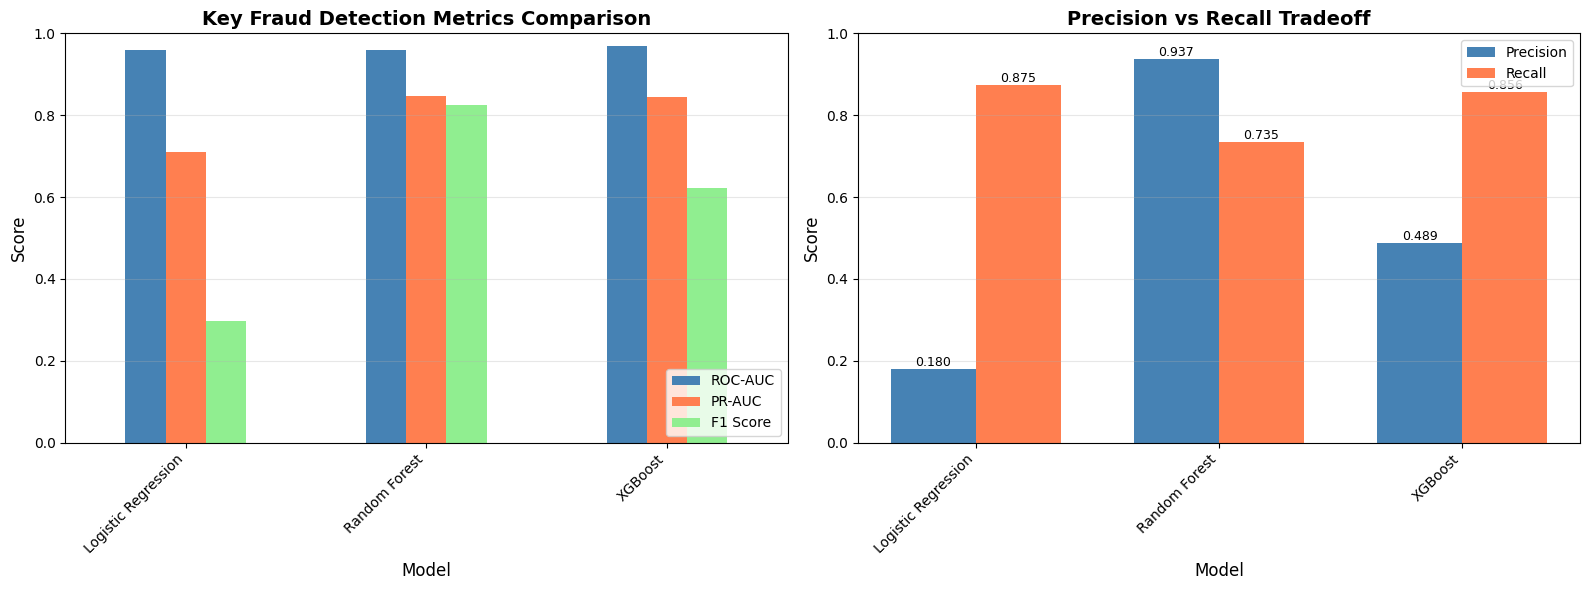

In [48]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Key metrics comparison (ROC-AUC, PR-AUC, F1)
ax = axes[0]
metrics_to_plot = ['roc_auc', 'pr_auc', 'f1']
comparison_df[metrics_to_plot].plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'lightgreen'])
ax.set_title('Key Fraud Detection Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend(['ROC-AUC', 'PR-AUC', 'F1 Score'], loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# Plot 2: Precision vs Recall tradeoff
ax = axes[1]
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['precision'], width, label='Precision', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['recall'], width, label='Recall', color='coral')

ax.set_title('Precision vs Recall Tradeoff', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Proceeed with model tuning (RF, XGBoost models)

In [49]:
def tune_with_logging(search_object, X, y, model_name):
    """
    Fit hyperparameter search with verbose output redirected to log file.
    
    Note: When using n_jobs=-1 (parallel processing), sklearn spawns subprocesses
    that don't inherit stdout redirection. Only the main summary line will be captured
    in the log file. Detailed CV results are saved to a separate CSV file.
    
    Parameters:
    -----------
    search_object : GridSearchCV or RandomizedSearchCV
        The search object to fit (configured with verbose=2 or higher)
    X : array-like
        Training features
    y : array-like
        Training target
    model_name : str
        Name of the model (e.g., 'random_forest', 'xgboost')
        Used for log file naming
    
    Returns:
    --------
    search_object : fitted search object
    log_path : str
        Path to the log file containing verbose output (summary only for parallel jobs)
    csv_path : str
        Path to the CSV file with detailed CV results
    """
    # Create log directory
    log_dir = Path(model_dir) / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)
    
    # Create timestamped file paths
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    log_path = log_dir / f"{model_name}_tuning_{timestamp}.log"
    csv_path = log_dir / f"{model_name}_cv_results_{timestamp}.csv"

    print("\nStarting hyperparameter search...")
    print(f"Verbose output will be saved to: {log_path}")
    print(f"CV results will be saved to: {csv_path}")
    
    # Fit with output redirection
    with open(log_path, 'w') as log_file:
        # Save original stdout/stderr
        original_stdout = sys.stdout
        original_stderr = sys.stderr
        
        try:
            # Redirect stdout and stderr to log file
            sys.stdout = log_file
            sys.stderr = log_file
            
            # Run the hyperparameter search
            search_object.fit(X, y)
            
        finally:
            # Restore original stdout/stderr
            sys.stdout = original_stdout
            sys.stderr = original_stderr
    
    # Save detailed CV results to CSV
    cv_results_df = pd.DataFrame(search_object.cv_results_)
    cv_results_df.to_csv(csv_path, index=False)
    
    print(f"✓ Verbose output saved to: {log_path}")
    print(f"✓ Detailed CV results saved to: {csv_path}")
    
    print("\n" + "=" * 80)
    print(f"{model_name} Tuning Complete!")
    print("=" * 80)
    print(f"Best cross-validation PR-AUC: {search_object.best_score_:.4f}")
    print(f"\nBest hyperparameters:")
    for param, value in search_object.best_params_.items():
        print(f"  • {param.replace('classifier__', '')}: {value}")
    print("=" * 80)
    
    return search_object, str(log_path), str(csv_path)


def create_search_object(search_type, estimator, param_grid, scoring, cv, 
                         n_iter=None, verbose=1, random_state=None, n_jobs=-1):
    """
    Create either RandomizedSearchCV or GridSearchCV based on search_type parameter.
    
    Parameters:
    -----------
    search_type : str
        Type of search: 'random' for RandomizedSearchCV, 'grid' for GridSearchCV
    estimator : estimator object
        The object to use to fit the data (e.g., Pipeline)
    param_grid : dict
        Dictionary with parameters names (str) as keys and lists of parameter settings
        For RandomizedSearchCV: Can be distributions
        For GridSearchCV: Will exhaustively search all combinations
    scoring : str or callable
        Strategy to evaluate the performance (e.g., 'average_precision')
    cv : cross-validation generator
        Cross-validation splitting strategy (e.g., StratifiedKFold)
    n_iter : int, optional
        Number of parameter settings sampled (only used for RandomizedSearchCV)
        If None and search_type='random', defaults to 10
    verbose : int, default=1
        Controls verbosity level
    random_state : int, default=None
        Random state for reproducibility
    n_jobs : int, default=-1
        Number of jobs to run in parallel
    
    Returns:
    --------
    search_object : GridSearchCV or RandomizedSearchCV
        Configured search object ready to fit
    
    Examples:
    ---------
    # GridSearchCV - exhaustive search
    search = create_search_object(
        search_type='grid',
        estimator=pipeline,
        param_grid={'n_estimators': [100, 200], 'max_depth': [10, 20]},
        scoring='average_precision',
        cv=cv_strategy
    )
    
    # RandomizedSearchCV - random sampling
    search = create_search_object(
        search_type='random',
        estimator=pipeline,
        param_grid={'n_estimators': [100, 200, 300], 'max_depth': range(5, 30)},
        scoring='average_precision',
        cv=cv_strategy,
        n_iter=40
    )
    """
    if search_type.lower() == 'grid':
        # GridSearchCV - exhaustive search over all combinations
        search_object = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=scoring,
            cv=cv,
            verbose=verbose,
            n_jobs=n_jobs
        )
        total_combinations = 1
        for param_values in param_grid.values():
            total_combinations *= len(param_values)
        print(f"Using GridSearchCV - will test all {total_combinations:,} combinations")
        
    elif search_type.lower() == 'random':
        # RandomizedSearchCV - random sampling of parameter combinations
        if n_iter is None:
            n_iter = 10
            print("Warning: n_iter not specified for RandomizedSearchCV, using default=10")
        
        search_object = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring=scoring,
            cv=cv,
            verbose=verbose,
            random_state=random_state,
            n_jobs=n_jobs
        )
        total_combinations = 1
        for param_values in param_grid.values():
            total_combinations *= len(param_values)
        print(f"Using RandomizedSearchCV - sampling {n_iter} from {total_combinations:,} possible combinations")
        
    else:
        raise ValueError(f"search_type must be 'grid' or 'random', got '{search_type}'")
    
    return search_object


def analyze_cv_results(cv_results_path, top_n=5, model_name="Model"):
    """
    Analyze cross-validation results with focus on production deployment criteria.
    
    ⚠ IMPORTANT: Timing measurements from parallel CV are unreliable - use as rough indicators only!
    Production API latency testing will provide definitive performance numbers.
    
    This function examines:
    - Model stability (std_test_score) - ✓ RELIABLE: consistency across CV folds
    - Performance (mean_test_score) - ✓ RELIABLE: PR-AUC for model selection
    - Prediction time (mean_score_time) - ⚠ UNRELIABLE: affected by parallel processing artifacts
    - Training time (mean_fit_time) - ⚠ UNRELIABLE: includes CV overhead
    
    Parameters:
    -----------
    cv_results_path : str
        Path to the CV results CSV file
    top_n : int, default=5
        Number of top candidates to analyze in detail
    model_name : str, default="Model"
        Name of the model for display purposes
    
    Returns:
    --------
    top_candidates : pd.DataFrame
        Top N candidates with detailed metrics
    """
    # Load CV results
    cv_results = pd.read_csv(cv_results_path)
    
    print("\n" + "=" * 100)
    print(f"{model_name} - Cross-Validation Results Analysis")
    print("=" * 100)
    print("⚠  TIMING CAVEAT: Due to parallel processing (n_jobs=-1), timing measurements may be")
    print("   unreliable. Small differences (< 20-30%) are often just measurement noise.")
    print("   Focus on PR-AUC and stability for model selection. Production API testing will")
    print("   provide definitive latency numbers.")
    print("=" * 100)
    
    # Extract key columns
    key_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
                'std_fit_time', 'mean_score_time', 'std_score_time', 'rank_test_score']
    
    # Add parameter columns
    param_cols = [col for col in cv_results.columns if col.startswith('param_')]
    display_cols = key_cols + param_cols
    
    # Get top N candidates by test score
    top_candidates = cv_results.nlargest(top_n, 'mean_test_score')[display_cols].copy()
    
    # Display top candidates
    print(f"\nTop {top_n} Candidates by PR-AUC:")
    print("-" * 100)
    display(top_candidates.style.format({
        'mean_test_score': '{:.6f}',
        'std_test_score': '{:.6f}',
        'mean_fit_time': '{:.2f}',
        'std_fit_time': '{:.2f}',
        'mean_score_time': '{:.4f}',
        'std_score_time': '{:.4f}'
    }).background_gradient(cmap='RdYlGn', subset=['mean_test_score']))
    
    # Statistical summary
    print("\n" + "-" * 100)
    print("Statistical Summary Across All Candidates:")
    print("-" * 100)
    summary_stats = cv_results[key_cols[:-1]].describe().loc[['mean', 'std', 'min', 'max']]
    display(summary_stats.style.format('{:.6f}'))
    
    # Best model analysis
    best_idx = cv_results['rank_test_score'].idxmin()
    best_model = cv_results.loc[best_idx]
    
    print("\n" + "-" * 100)
    print("Best Model (Rank 1) - Detailed Metrics:")
    print("-" * 100)
    print(f"  • PR-AUC (mean ± std):        {best_model['mean_test_score']:.6f} ± {best_model['std_test_score']:.6f}")
    print(f"  • Stability (CV std):         {best_model['std_test_score']:.6f} {'✓ Stable' if best_model['std_test_score'] < 0.01 else '⚠ Variable'}")
    print(f"  • Training time (mean ± std): {best_model['mean_fit_time']:.2f}s ± {best_model['std_fit_time']:.2f}s (⚠ unreliable)")
    print(f"  • Prediction time (mean ± std): {best_model['mean_score_time']:.4f}s ± {best_model['std_score_time']:.4f}s (⚠ unreliable)")
    print(f"  • Est. throughput:            ~{1/best_model['mean_score_time']:.0f} predictions/sec (⚠ unreliable)")
    print("-" * 100)
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Performance vs Stability
    ax = axes[0, 0]
    scatter = ax.scatter(cv_results['mean_test_score'], 
                        cv_results['std_test_score'],
                        c=cv_results['rank_test_score'],
                        cmap='RdYlGn_r',
                        s=100,
                        alpha=0.6,
                        edgecolors='black')
    
    # Highlight best model
    ax.scatter(best_model['mean_test_score'], 
              best_model['std_test_score'],
              c='red',
              s=300,
              marker='*',
              edgecolors='black',
              linewidths=2,
              label='Best Model',
              zorder=10)
    
    ax.set_xlabel('Mean PR-AUC (Test Score) - ✓ Reliable', fontsize=12)
    ax.set_ylabel('Std PR-AUC (Stability) - ✓ Reliable', fontsize=12)
    ax.set_title('Performance vs Stability (Both Metrics Reliable)', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='Rank')
    
    # Plot 2: Performance vs Prediction Time
    ax = axes[0, 1]
    scatter = ax.scatter(cv_results['mean_test_score'], 
                        cv_results['mean_score_time'],
                        c=cv_results['rank_test_score'],
                        cmap='RdYlGn_r',
                        s=100,
                        alpha=0.6,
                        edgecolors='black')
    
    # Highlight best model
    ax.scatter(best_model['mean_test_score'], 
              best_model['mean_score_time'],
              c='red',
              s=300,
              marker='*',
              edgecolors='black',
              linewidths=2,
              label='Best Model',
              zorder=10)
    
    ax.set_xlabel('Mean PR-AUC - ✓ Reliable', fontsize=12)
    ax.set_ylabel('Mean Prediction Time - ⚠ Unreliable', fontsize=12)
    ax.set_title('Performance vs Prediction Time (Time Unreliable)', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='Rank')
    
    # Plot 3: Top N Candidates Comparison
    ax = axes[1, 0]
    x = np.arange(len(top_candidates))
    width = 0.35
    
    # Normalize scores for comparison
    score_normalized = (top_candidates['mean_test_score'] - cv_results['mean_test_score'].min()) / \
                       (cv_results['mean_test_score'].max() - cv_results['mean_test_score'].min())
    time_normalized = 1 - (top_candidates['mean_score_time'] - cv_results['mean_score_time'].min()) / \
                      (cv_results['mean_score_time'].max() - cv_results['mean_score_time'].min())
    
    bars1 = ax.bar(x - width/2, score_normalized, width, label='Performance ✓', color='steelblue')
    bars2 = ax.bar(x + width/2, time_normalized, width, label='Speed ⚠', color='coral')
    
    ax.set_xlabel('Candidate Rank', fontsize=12)
    ax.set_ylabel('Normalized Score', fontsize=12)
    ax.set_title(f'Top {top_n} Candidates: Performance ✓ vs Speed ⚠', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Rank {int(r)}" for r in top_candidates['rank_test_score']])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])
    
    # Plot 4: Training Time vs Prediction Time
    ax = axes[1, 1]
    scatter = ax.scatter(cv_results['mean_fit_time'], 
                        cv_results['mean_score_time'],
                        c=cv_results['mean_test_score'],
                        cmap='RdYlGn',
                        s=100,
                        alpha=0.6,
                        edgecolors='black')
    
    # Highlight best model
    ax.scatter(best_model['mean_fit_time'], 
              best_model['mean_score_time'],
              c='red',
              s=300,
              marker='*',
              edgecolors='black',
              linewidths=2,
              label='Best Model',
              zorder=10)
    
    ax.set_xlabel('Mean Training Time - ⚠ Unreliable', fontsize=12)
    ax.set_ylabel('Mean Prediction Time - ⚠ Unreliable', fontsize=12)
    ax.set_title('Training vs Prediction Time (Both Unreliable)', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='PR-AUC')
    
    plt.tight_layout()
    plt.show()
    
    # Recommendations
    print("\n" + "=" * 100)
    print("Model Selection Recommendations:")
    print("=" * 100)
    
    # Check stability (RELIABLE)
    if best_model['std_test_score'] < 0.005:
        print("✓ STABILITY: Excellent (std < 0.005) - consistent performance across CV folds")
    elif best_model['std_test_score'] < 0.01:
        print("✓ STABILITY: Good (std < 0.01) - acceptable for production")
    else:
        print("⚠ STABILITY: High variance (std >= 0.01) - consider more data or regularization")
    
    # Timing caveats
    print(f"\n⚠ TIMING: CV measurements unreliable due to parallel processing artifacts.")
    print(f"  CV reported: {best_model['mean_score_time']:.4f}s prediction time - DO NOT rely on this!")
    print(f"  Recommendation: Measure latency in production API deployment for accurate numbers.")
    
    # Trade-off analysis
    if len(top_candidates) > 1:
        # Find fastest model in top 5 (even though timing is unreliable, show the pattern)
        fastest_idx = top_candidates['mean_score_time'].idxmin()
        fastest_model = top_candidates.loc[fastest_idx]
        
        score_diff = best_model['mean_test_score'] - fastest_model['mean_test_score']
        
        if score_diff < 0.001:
            print(f"\n💡 TRADE-OFF NOTE: Multiple top models have nearly identical PR-AUC (< 0.001 difference).")
            print(f"   If production latency becomes an issue, simpler models can be tested with minimal")
            print(f"   performance cost. Focus on PR-AUC now; optimize for speed in production if needed.")
    
    print("\n" + "=" * 100)
    print("SUMMARY: Select model based on PR-AUC and stability. Evaluate latency in production.")
    print("=" * 100)
    
    return top_candidates

In [50]:
# Define cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

#### Tuning RandomForest

In [41]:
print("=" * 80)

# SEARCH CONFIGURATION - easily switch between Grid and Random search
# Note that I have not included the random search as it took > 30 minutes to run
# Logs of previous runs can be viewed at models/logs/*.txt
search_type = 'grid'  # Options: 'grid' for GridSearchCV, 'random' for RandomizedSearchCV
n_iter = 40  # Only used if search_type='random'

# Define hyperparameter grid
param_grid_rf = {
    'classifier__n_estimators': [400, 450],
    'classifier__max_depth': [20, 25, 30],
    'classifier__min_samples_split': [2],
    'classifier__min_samples_leaf': [2],
    'classifier__max_features': ['sqrt'],
    'classifier__class_weight': ['balanced_subsample']
}

print(f"Hyperparameter search space:")
print(f"  • n_estimators: {param_grid_rf['classifier__n_estimators']}")
print(f"  • max_depth: {param_grid_rf['classifier__max_depth']}")
print(f"  • min_samples_split: {param_grid_rf['classifier__min_samples_split']}")
print(f"  • min_samples_leaf: {param_grid_rf['classifier__min_samples_leaf']}")
print(f"  • max_features: {param_grid_rf['classifier__max_features']}")
print(f"  • class_weight: {param_grid_rf['classifier__class_weight']}")
print("=" * 80)

# Create base pipeline
rf_base_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=1,
        n_jobs=-1
    ))
])

# Create search object (Grid or Random based on search_type)
rf_search = create_search_object(
    search_type=search_type,
    estimator=rf_base_pipeline,
    param_grid=param_grid_rf,
    scoring='average_precision',  # PR-AUC
    cv=cv_strategy,
    n_iter=n_iter,  # Only used for RandomizedSearchCV
    verbose=1,  # Minimal output (CSV has all details)
    random_state=1,
    n_jobs=-1
)

# Fit with logging
rf_search, rf_log_path, rf_cv_results_path = tune_with_logging(
    rf_search, 
    X_train, 
    y_train, 
    model_name='random_forest'
)

Hyperparameter search space:
  • n_estimators: [400, 450]
  • max_depth: [20, 25, 30]
  • min_samples_split: [2]
  • min_samples_leaf: [2]
  • max_features: ['sqrt']
  • class_weight: ['balanced_subsample']
Using GridSearchCV - will test all 6 combinations

Starting hyperparameter search...
Verbose output will be saved to: models/logs/random_forest_tuning_20251120_105122.log
CV results will be saved to: models/logs/random_forest_cv_results_20251120_105122.csv
✓ Verbose output saved to: models/logs/random_forest_tuning_20251120_105122.log
✓ Detailed CV results saved to: models/logs/random_forest_cv_results_20251120_105122.csv

random_forest Tuning Complete!
Best cross-validation PR-AUC: 0.8614

Best hyperparameters:
  • class_weight: balanced_subsample
  • max_depth: 25
  • max_features: sqrt
  • min_samples_leaf: 2
  • min_samples_split: 2
  • n_estimators: 450


In [42]:
# Evaluate tuned RF on validation dataset
rf_tuned_metrics = evaluate_model(
    rf_search.best_estimator_, 
    X_val, 
    y_val, 
    model_name="Random Forest (Tuned)",
    dataset_name="Validation"
)

# Compare with baseline
print("\n" + "=" * 80)
print("Random Forest: Baseline vs Tuned")
print("=" * 80)
comparison_rf = pd.DataFrame([rf_metrics, rf_tuned_metrics])
comparison_rf = comparison_rf.set_index('model')
comparison_rf = comparison_rf.drop(columns=['dataset'])
display(comparison_rf)

# Calculate improvements
print("\nImprovements:")
for metric in ['pr_auc', 'f1', 'precision', 'recall']:
    baseline_val = rf_metrics[metric]
    tuned_val = rf_tuned_metrics[metric]
    improvement = tuned_val - baseline_val
    improvement_pct = (improvement / baseline_val) * 100
    symbol = "↑" if improvement > 0 else "↓" if improvement < 0 else "="
    print(f"  {metric.upper():12s}: {baseline_val:.4f} → {tuned_val:.4f} ({symbol} {improvement:+.4f}, {improvement_pct:+.1f}%)")
print("=" * 80)


Random Forest (Tuned) - Validation Set Performance:
  ROC-AUC:    0.9727
  PR-AUC:     0.8621
  F1 Score:   0.8230
  Precision:  0.8988
  Recall:     0.7589
  Accuracy:   0.9928

Confusion Matrix:
  TN: 58,503  |  FP: 113
  FN: 319  |  TP: 1,004

Random Forest: Baseline vs Tuned


,roc_auc,pr_auc,f1,precision,recall,accuracy
model,,,,,,
Random Forest,0.962307,0.852738,0.819080,0.949203,0.720333,0.992976
Random Forest (Tuned),0.972653,0.862074,0.822951,0.898836,0.758881,0.992793



Improvements:
  PR_AUC      : 0.8527 → 0.8621 (↑ +0.0093, +1.1%)
  F1          : 0.8191 → 0.8230 (↑ +0.0039, +0.5%)
  PRECISION   : 0.9492 → 0.8988 (↓ -0.0504, -5.3%)
  RECALL      : 0.7203 → 0.7589 (↑ +0.0385, +5.4%)


#### Tuning XGBoost

In [53]:
search_type = 'grid'  # Options: 'grid' for GridSearchCV, 'random' for RandomizedSearchCV
n_iter = 50  # Only used if search_type='random'

# Define hyperparameter grid
param_grid_xgb = {
    'classifier__n_estimators': [90, 110, 130],
    'classifier__max_depth': [4, 5, 6],
    'classifier__learning_rate': [0.08, 0.12, 0.18],
    'classifier__subsample': [0.9],
    'classifier__colsample_bytree': [0.9],
    'classifier__min_child_weight': [3, 5],
    'classifier__gamma': [0.4, 0.5, 0.6],
    'classifier__scale_pos_weight': [8, 10, 12]
}

print(f"Hyperparameter search space:")
print(f"  • n_estimators: {param_grid_xgb['classifier__n_estimators']}")
print(f"  • max_depth: {param_grid_xgb['classifier__max_depth']}")
print(f"  • learning_rate: {param_grid_xgb['classifier__learning_rate']}")
print(f"  • subsample: {param_grid_xgb['classifier__subsample']}")
print(f"  • colsample_bytree: {param_grid_xgb['classifier__colsample_bytree']}")
print(f"  • min_child_weight: {param_grid_xgb['classifier__min_child_weight']}")
print(f"  • gamma: {param_grid_xgb['classifier__gamma']}")
print(f"  • scale_pos_weight: {param_grid_xgb['classifier__scale_pos_weight']}")
print("=" * 80)

# Create base pipeline
xgb_base_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', xgb.XGBClassifier(
        #scale_pos_weight=scale_pos_weight,  # Keep class imbalance handling
        random_state=1,
        n_jobs=-1,
        eval_metric='aucpr'
        #eval_metric='logloss'
    ))
])

# Create search object (Grid or Random based on search_type)
xgb_search = create_search_object(
    search_type=search_type,
    estimator=xgb_base_pipeline,
    param_grid=param_grid_xgb,
    scoring='average_precision',  # PR-AUC
    cv=cv_strategy,
    n_iter=n_iter,  # Only used for RandomizedSearchCV
    verbose=1,  # Minimal output (CSV has all details)
    random_state=1,
    n_jobs=-1
)

# Fit with logging
xgb_search, xgb_log_path, xgb_cv_results_path = tune_with_logging(
    xgb_search, 
    X_train, 
    y_train, 
    model_name='xgboost'
)

Hyperparameter search space:
  • n_estimators: [90, 110, 130]
  • max_depth: [4, 5, 6]
  • learning_rate: [0.08, 0.12, 0.18]
  • subsample: [0.9]
  • colsample_bytree: [0.9]
  • min_child_weight: [3, 5]
  • gamma: [0.4, 0.5, 0.6]
  • scale_pos_weight: [8, 10, 12]
Using GridSearchCV - will test all 486 combinations

Starting hyperparameter search...
Verbose output will be saved to: models/logs/xgboost_tuning_20251120_211038.log
CV results will be saved to: models/logs/xgboost_cv_results_20251120_211038.csv
✓ Verbose output saved to: models/logs/xgboost_tuning_20251120_211038.log
✓ Detailed CV results saved to: models/logs/xgboost_cv_results_20251120_211038.csv

xgboost Tuning Complete!
Best cross-validation PR-AUC: 0.8673

Best hyperparameters:
  • colsample_bytree: 0.9
  • gamma: 0.6
  • learning_rate: 0.12
  • max_depth: 4
  • min_child_weight: 5
  • n_estimators: 90
  • scale_pos_weight: 8
  • subsample: 0.9


In [55]:
# evaluate tuned XGBoost on validation dataset
xgb_tuned_metrics = evaluate_model(
    xgb_search.best_estimator_, 
    X_val, 
    y_val, 
    model_name="XGBoost (Tuned)",
    dataset_name="Validation"
)

# Compare with baseline
print("\n" + "=" * 80)
print("XGBoost: Baseline vs Tuned")
print("=" * 80)
comparison_xgb = pd.DataFrame([xgb_metrics, xgb_tuned_metrics])
comparison_xgb = comparison_xgb.set_index('model')
comparison_xgb = comparison_xgb.drop(columns=['dataset'])
display(comparison_xgb)

# Calculate improvements
print("\nImprovements:")
for metric in ['pr_auc', 'f1', 'precision', 'recall']:
    baseline_val = xgb_metrics[metric]
    tuned_val = xgb_tuned_metrics[metric]
    improvement = tuned_val - baseline_val
    improvement_pct = (improvement / baseline_val) * 100
    symbol = "↑" if improvement > 0 else "↓" if improvement < 0 else "="
    print(f"  {metric.upper():12s}: {baseline_val:.4f} → {tuned_val:.4f} ({symbol} {improvement:+.4f}, {improvement_pct:+.1f}%)")
print("=" * 80)


XGBoost (Tuned) - Validation Set Performance:
  ROC-AUC:    0.9791
  PR-AUC:     0.8674
  F1 Score:   0.7741
  Precision:  0.7213
  Recall:     0.8352
  Accuracy:   0.9892

Confusion Matrix:
  TN: 58,189  |  FP: 427
  FN: 218  |  TP: 1,105

XGBoost: Baseline vs Tuned


,roc_auc,pr_auc,f1,precision,recall,accuracy
model,,,,,,
XGBoost,0.969857,0.845582,0.621978,0.488563,0.855631,0.977043
XGBoost (Tuned),0.979058,0.867373,0.774081,0.721279,0.835223,0.989239



Improvements:
  PR_AUC      : 0.8456 → 0.8674 (↑ +0.0218, +2.6%)
  F1          : 0.6220 → 0.7741 (↑ +0.1521, +24.5%)
  PRECISION   : 0.4886 → 0.7213 (↑ +0.2327, +47.6%)
  RECALL      : 0.8556 → 0.8352 (↓ -0.0204, -2.4%)


In [56]:
all_models_comparison = pd.DataFrame([
    logistic_metrics,
    rf_metrics,
#    rf_tuned_metrics,
    xgb_metrics,
    xgb_tuned_metrics
])
all_models_comparison = all_models_comparison.set_index('model')
all_models_comparison = all_models_comparison.drop(columns=['dataset'])

print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON - Validation Set")
print("="*100)
display(all_models_comparison.style.format({
    'roc_auc': '{:.4f}',
    'pr_auc': '{:.4f}',
    'f1': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'accuracy': '{:.4f}'
}).background_gradient(cmap='RdYlGn', subset=['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']))

# Identify best model for each metric
print("\n" + "="*100)
print("Best Performing Model by Metric:")
print("="*100)
for metric in ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']:
    best_model = all_models_comparison[metric].idxmax()
    best_value = all_models_comparison[metric].max()
    print(f"  {metric.upper():15s}: {best_model:30s} ({best_value:.4f})")
print("="*100)

# Select best overall model based on PR-AUC (our optimization metric)
best_model_name = all_models_comparison['pr_auc'].idxmax()
best_model_prauc = all_models_comparison['pr_auc'].max()
print(f"\n🏆 BEST MODEL (by PR-AUC): {best_model_name}")
print(f"   PR-AUC: {best_model_prauc:.4f}")
print("="*100)


COMPREHENSIVE MODEL COMPARISON - Validation Set


,roc_auc,pr_auc,f1,precision,recall,accuracy
model,,,,,,
Logistic Regression,0.9601,0.7102,0.2981,0.1797,0.8745,0.9091
Random Forest,0.9600,0.8473,0.8242,0.9374,0.7354,0.9931
XGBoost,0.9699,0.8456,0.6220,0.4886,0.8556,0.9770
XGBoost (Tuned),0.9791,0.8674,0.7741,0.7213,0.8352,0.9892



Best Performing Model by Metric:
  ROC_AUC        : XGBoost (Tuned)                (0.9791)
  PR_AUC         : XGBoost (Tuned)                (0.8674)
  F1             : Random Forest                  (0.8242)
  PRECISION      : Random Forest                  (0.9374)
  RECALL         : Logistic Regression            (0.8745)

🏆 BEST MODEL (by PR-AUC): XGBoost (Tuned)
   PR-AUC: 0.8674


#### Retrain final model on train&validation datasets

In [57]:
# Combine training and validation datasets
print("Combining training and validation datasets...")
train_val_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

X_train_val = train_val_df.drop(columns=[target_col])
y_train_val = train_val_df[target_col]

print(f"Combined dataset shape: {train_val_df.shape}")
print(f"  • Training set:   {train_df.shape[0]:,} samples")
print(f"  • Validation set: {val_df.shape[0]:,} samples")
print(f"  • Combined:       {train_val_df.shape[0]:,} samples")
print(f"  • Increase:       +{train_val_df.shape[0] - train_df.shape[0]:,} samples (+{(train_val_df.shape[0] - train_df.shape[0])/train_df.shape[0]*100:.1f}%)")
print(f"\nFraud rate in combined set: {y_train_val.mean():.4f} ({y_train_val.mean()*100:.2f}%)")
print(f"Class imbalance ratio: {(y_train_val == 0).sum() / (y_train_val == 1).sum():.1f}:1")

Combining training and validation datasets...
Combined dataset shape: (239756, 15)
  • Training set:   179,817 samples
  • Validation set: 59,939 samples
  • Combined:       239,756 samples
  • Increase:       +59,939 samples (+33.3%)

Fraud rate in combined set: 0.0221 (2.21%)
Class imbalance ratio: 44.3:1


In [58]:
# Create final production model with optimal hyperparameters
print("\n" + "=" * 100)
print("RETRAINING FINAL MODEL ON TRAIN+VAL COMBINED")
print("=" * 100)

print("\nUsing optimal hyperparameters from GridSearchCV:")
for param, value in xgb_search.best_params_.items():
    print(f"  • {param.replace('classifier__', '')}: {value}")

# Create final pipeline with optimal hyperparameters
final_xgb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=xgb_search.best_params_['classifier__n_estimators'],
        max_depth=xgb_search.best_params_['classifier__max_depth'],
        learning_rate=xgb_search.best_params_['classifier__learning_rate'],
        subsample=xgb_search.best_params_['classifier__subsample'],
        colsample_bytree=xgb_search.best_params_['classifier__colsample_bytree'],
        min_child_weight=xgb_search.best_params_['classifier__min_child_weight'],
        gamma=xgb_search.best_params_['classifier__gamma'],
        scale_pos_weight=xgb_search.best_params_['classifier__scale_pos_weight'],
        eval_metric='aucpr',
        random_state=1,
        n_jobs=-1
    ))
])

print("\nTraining final model on combined train+val data...")
final_xgb_pipeline.fit(X_train_val, y_train_val)

print("✓ Final model trained successfully")
print(f"  • Training samples: {len(X_train_val):,}")
print(f"  • Features: {X_train_val.shape[1]}")
print(f"  • Fraud rate: {y_train_val.mean():.4f}")
print("=" * 100)


RETRAINING FINAL MODEL ON TRAIN+VAL COMBINED

Using optimal hyperparameters from GridSearchCV:
  • colsample_bytree: 0.9
  • gamma: 0.6
  • learning_rate: 0.12
  • max_depth: 4
  • min_child_weight: 5
  • n_estimators: 90
  • scale_pos_weight: 8
  • subsample: 0.9

Training final model on combined train+val data...
✓ Final model trained successfully
  • Training samples: 239,756
  • Features: 14
  • Fraud rate: 0.0221


In [59]:
# Prepare test set
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("Test set prepared:")
print(f"  • Features shape: {X_test.shape}")
print(f"  • Target shape: {y_test.shape}")
print(f"  • Fraud rate: {y_test.mean():.4f} ({y_test.mean()*100:.2f}%)")

# Evaluate final retrained model on test set
final_test_metrics = evaluate_model(
    final_xgb_pipeline,
    X_test,
    y_test,
    model_name="XGBoost (Final - Retrained on Train+Val)",
    dataset_name="Test"
)

Test set prepared:
  • Features shape: (59939, 14)
  • Target shape: (59939,)
  • Fraud rate: 0.0221 (2.21%)

XGBoost (Final - Retrained on Train+Val) - Test Set Performance:
  ROC-AUC:    0.9771
  PR-AUC:     0.8657
  F1 Score:   0.7793
  Precision:  0.7370
  Recall:     0.8268
  Accuracy:   0.9897

Confusion Matrix:
  TN: 58,227  |  FP: 390
  FN: 229  |  TP: 1,093


In [60]:
# Compare validation vs test performance
print("\n" + "=" * 100)
print("VALIDATION VS TEST SET PERFORMANCE")
print("=" * 100)
print("Note: Validation performance from model trained on train set only")
print("      Test performance from final model trained on train+val combined")
print("=" * 100)

comparison_val_test = pd.DataFrame([xgb_tuned_metrics, final_test_metrics])
comparison_val_test = comparison_val_test.set_index('dataset')
comparison_val_test = comparison_val_test.drop(columns=['model'])

display(comparison_val_test.style.format({
    'roc_auc': '{:.4f}',
    'pr_auc': '{:.4f}',
    'f1': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'accuracy': '{:.4f}'
}).background_gradient(cmap='RdYlGn', subset=['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']))

# Calculate differences
print("\nPerformance Differences (Test - Validation):")
print("-" * 100)
for metric in ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']:
    val_score = xgb_tuned_metrics[metric]
    test_score = final_test_metrics[metric]
    diff = test_score - val_score
    diff_pct = (diff / val_score) * 100
    symbol = "↑" if diff > 0 else "↓" if diff < 0 else "="
    
    # Determine if difference is concerning
    if abs(diff_pct) < 1:
        status = "✓ Excellent"
    elif abs(diff_pct) < 2:
        status = "✓ Good"
    elif abs(diff_pct) < 5:
        status = "⚠ Acceptable"
    else:
        status = "❌ Concerning"
    
    print(f"  {metric.upper():12s}: {val_score:.4f} → {test_score:.4f} ({symbol} {diff:+.4f}, {diff_pct:+.2f}%) - {status}")

print("-" * 100)

# Overall assessment
avg_diff_pct = abs((final_test_metrics['pr_auc'] - xgb_tuned_metrics['pr_auc']) / xgb_tuned_metrics['pr_auc'] * 100)
if avg_diff_pct < 1:
    print("\n✅ GENERALIZATION: Excellent - final model generalizes very well to unseen data")
elif avg_diff_pct < 2:
    print("\n✅ GENERALIZATION: Good - final model shows stable performance on test set")
elif avg_diff_pct < 5:
    print("\n⚠ GENERALIZATION: Acceptable - minor performance difference, monitor in production")
else:
    print("\n❌ GENERALIZATION: Poor - significant performance gap, consider regularization")

# Compare with expected improvement from more training data
if final_test_metrics['pr_auc'] > xgb_tuned_metrics['pr_auc']:
    print(f"\n💡 INSIGHT: Test performance improved despite being on unseen data!")
    print(f"   This is expected because the final model was trained on 33% more data (train+val)")
elif final_test_metrics['pr_auc'] >= xgb_tuned_metrics['pr_auc'] * 0.98:
    print(f"\n💡 INSIGHT: Test performance maintained despite being on completely unseen data")
    print(f"   Extra training data (train+val) helped maintain generalization")

print("=" * 100)


VALIDATION VS TEST SET PERFORMANCE
Note: Validation performance from model trained on train set only
      Test performance from final model trained on train+val combined


,roc_auc,pr_auc,f1,precision,recall,accuracy
dataset,,,,,,
Validation,0.9791,0.8674,0.7741,0.7213,0.8352,0.9892
Test,0.9771,0.8657,0.7793,0.7370,0.8268,0.9897



Performance Differences (Test - Validation):
----------------------------------------------------------------------------------------------------
  ROC_AUC     : 0.9791 → 0.9771 (↓ -0.0019, -0.20%) - ✓ Excellent
  PR_AUC      : 0.8674 → 0.8657 (↓ -0.0016, -0.19%) - ✓ Excellent
  F1          : 0.7741 → 0.7793 (↑ +0.0052, +0.68%) - ✓ Excellent
  PRECISION   : 0.7213 → 0.7370 (↑ +0.0157, +2.18%) - ⚠ Acceptable
  RECALL      : 0.8352 → 0.8268 (↓ -0.0084, -1.01%) - ✓ Good
----------------------------------------------------------------------------------------------------

✅ GENERALIZATION: Excellent - final model generalizes very well to unseen data

💡 INSIGHT: Test performance maintained despite being on completely unseen data
   Extra training data (train+val) helped maintain generalization


#### Feature importance

XGBoost Feature Importance (Gain) - Top 20 Features (Final Retrained Model)


,feature,importance
2,avs_match,0.280416
4,account_age_days,0.166487
10,security_score,0.110489
7,shipping_distance_km,0.091799
3,three_ds_flag,0.070695
13,country_mismatch,0.065055
6,amount,0.052543
9,amount_vs_avg_ratio,0.050751
0,channel,0.038596
8,amount_deviation,0.038271


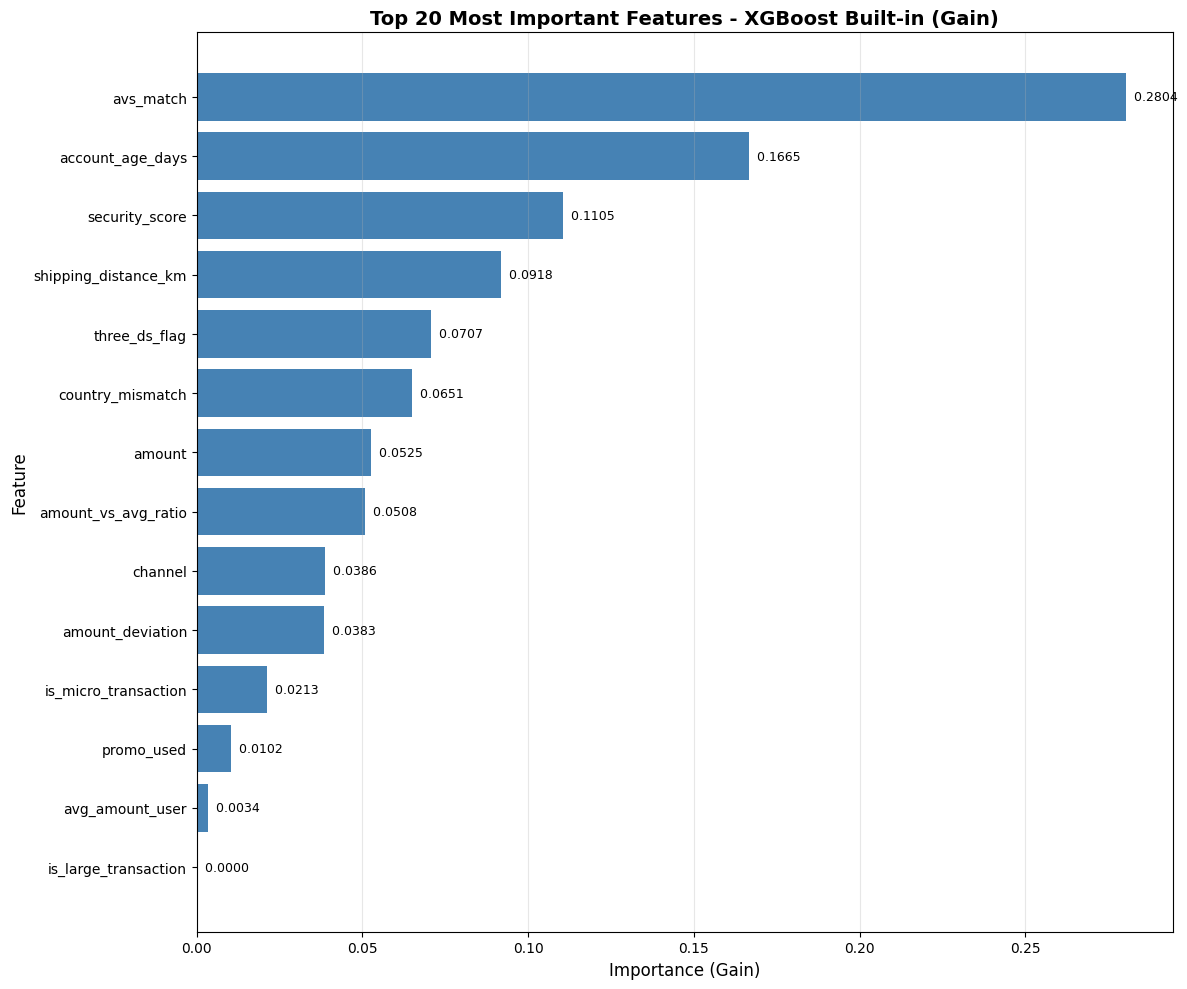


✓ XGBoost built-in feature importance analyzed (20 features shown)


In [61]:
# Extract XGBoost built-in feature importance from final retrained model
xgb_model = final_xgb_pipeline.named_steps['classifier']

# Get feature importance scores (gain)
importance_scores = xgb_model.feature_importances_

# Get feature names from the preprocessor
# After preprocessing, categorical features are encoded and continuous/binary are passed through
preprocessor = final_xgb_pipeline.named_steps['preprocessor']

# Categorical features are first in the ColumnTransformer
# Then continuous_numeric + binary features (passthrough)
feature_names = categorical + continuous_numeric + binary

# Create DataFrame with feature importance
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_scores
}).sort_values('importance', ascending=False)

print("=" * 100)
print("XGBoost Feature Importance (Gain) - Top 20 Features (Final Retrained Model)")
print("=" * 100)
display(feature_importance_df.head(20).style.format({'importance': '{:.6f}'}).background_gradient(cmap='RdYlGn', subset=['importance']))

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(12, 10))
top_n = 20
top_features = feature_importance_df.head(top_n)

ax.barh(range(len(top_features)), top_features['importance'], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features - XGBoost Built-in (Gain)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['importance'], i, f"  {row['importance']:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✓ XGBoost built-in feature importance analyzed ({top_n} features shown)")

In [62]:
# Feature Importance Summary
print("=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

# Display top 20 features
print("\nTop 20 Most Important Features for Fraud Detection:")
print("-" * 100)
for i, (idx, row) in enumerate(feature_importance_df.head(20).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']:40s} - Importance: {row['importance']:.6f}")

print("\n" + "=" * 100)
print("KEY INSIGHTS:")
print("=" * 100)

# Analyze top features
top_5 = feature_importance_df.head(5)['feature'].tolist()
print(f"\nTop 5 fraud indicators:")
for i, feat in enumerate(top_5, 1):
    print(f"  {i}. {feat}")

# Calculate cumulative importance
cumulative_importance = feature_importance_df['importance'].cumsum() / feature_importance_df['importance'].sum()

print(f"\nModel concentration:")
print(f"  • Top 5 features account for {cumulative_importance.iloc[4]:.1%} of total importance")
print(f"  • Top 10 features account for {cumulative_importance.iloc[9]:.1%} of total importance")

print("\n" + "=" * 100)
print("✓ Feature importance analysis complete")

FEATURE IMPORTANCE SUMMARY

Top 20 Most Important Features for Fraud Detection:
----------------------------------------------------------------------------------------------------
   1. avs_match                                - Importance: 0.280416
   2. account_age_days                         - Importance: 0.166487
   3. security_score                           - Importance: 0.110489
   4. shipping_distance_km                     - Importance: 0.091799
   5. three_ds_flag                            - Importance: 0.070695
   6. country_mismatch                         - Importance: 0.065055
   7. amount                                   - Importance: 0.052543
   8. amount_vs_avg_ratio                      - Importance: 0.050751
   9. channel                                  - Importance: 0.038596
  10. amount_deviation                         - Importance: 0.038271
  11. is_micro_transaction                     - Importance: 0.021308
  12. promo_used                               - 

### Train XGBoost model based on 14 most important features (time features could be ignored)

In [38]:
exclude_cols = id_cols + ['country', 'bin_country', 'merchant_category', 'transaction_time', 'local_time', 
                          'verification_failures', 'all_verifications_passed', 'all_verifications_failed', 
                         'total_transactions_user', 'high_risk_distance', 'hour_local', 'day_of_week_local', 
                          'month_local', 'is_weekend_local','is_late_night_local', 'is_business_hours_local', 
                         'cvv_result', 'is_high_frequency_user', 'is_new_account' ]

In [40]:
# Continuous numeric (need scaling for Logistic Regression)
continuous_numeric = [
    'account_age_days', 'avg_amount_user', 
    'amount', 'shipping_distance_km', 'amount_deviation', 'amount_vs_avg_ratio', 'security_score'
]

# Categorical features (need encoding)
categorical = ['channel', 'promo_used', 'avs_match', 'three_ds_flag']

# Binary features (no preprocessing)
binary = [
    'is_micro_transaction', 'is_large_transaction', 'country_mismatch'
]

print("Feature categorization for preprocessing:")
print(f"  • Continuous numeric: {len(continuous_numeric)}")
print(f"  • Categorical: {len(categorical)}")
print(f"  • Binary: {len(binary)}")
print(f"  • Total: {len(continuous_numeric) + len(categorical) + len(binary)}")

all_features = continuous_numeric + categorical + binary
assert len(all_features) == 14, f"Expected 14 features, got {len(all_features)}"
print("\n✓ All 14 features categorized correctly")

Feature categorization for preprocessing:
  • Continuous numeric: 7
  • Categorical: 4
  • Binary: 3
  • Total: 14

✓ All 14 features categorized correctly


In [63]:
# Calculate precision-recall curve for threshold optimization using validation set
# Get predictions from final retrained model on validation set
y_val_proba_final = final_xgb_pipeline.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_final)

# Function to find optimal threshold for target recall
def find_threshold_for_recall(target_recall, precisions, recalls, thresholds):
    """
    Find threshold that achieves target recall and maximizes precision.
    
    Returns: (threshold, precision, recall, f1)
    """
    # Find indices where recall >= target_recall
    valid_indices = np.where(recalls[:-1] >= target_recall)[0]
    
    if len(valid_indices) == 0:
        return None, None, None, None
    
    # Among valid thresholds, find the one with highest precision
    best_idx = valid_indices[np.argmax(precisions[:-1][valid_indices])]
    
    threshold = thresholds[best_idx]
    precision = precisions[best_idx]
    recall = recalls[best_idx]
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return threshold, precision, recall, f1


# Define recall targets
recall_targets = [0.90, 0.85, 0.80]
threshold_results = []

print("=" * 100)
print("THRESHOLD OPTIMIZATION - Finding Optimal Thresholds for Recall Targets")
print("=" * 100)
print("Using validation set predictions from final retrained model")
print("=" * 100)

for target_recall in recall_targets:
    threshold, precision, recall, f1 = find_threshold_for_recall(
        target_recall, precisions, recalls, thresholds
    )
    
    if threshold is not None:
        # Calculate confusion matrix at this threshold
        y_val_pred_custom = (y_val_proba_final >= threshold).astype(int)
        cm = confusion_matrix(y_val, y_val_pred_custom)
        tn, fp, fn, tp = cm.ravel()
        
        result = {
            'target_recall': target_recall,
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tn': tn,
            'fp': fp,
            'fn': fn,
            'tp': tp
        }
        threshold_results.append(result)
        
        print(f"\nTarget Recall: {target_recall*100:.0f}%")
        print(f"  • Optimal Threshold: {threshold:.4f}")
        print(f"  • Achieved Recall:   {recall:.4f} ({recall*100:.2f}%)")
        print(f"  • Precision:         {precision:.4f} ({precision*100:.2f}%)")
        print(f"  • F1 Score:          {f1:.4f}")
        print(f"  • Confusion Matrix:  TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}")
        print(f"  • False Positive Rate: {fp/(fp+tn)*100:.2f}%")
        print(f"  • False Negative Rate: {fn/(fn+tp)*100:.2f}%")

print("=" * 100)

# Create DataFrame for comparison
threshold_comparison = pd.DataFrame(threshold_results)
threshold_comparison['target_name'] = ['Conservative (90%)', 'Balanced (85%)', 'Aggressive (80%)']
threshold_comparison = threshold_comparison[['target_name', 'threshold', 'precision', 'recall', 'f1', 'fp', 'fn']]

print("\nThreshold Comparison Table:")
print("-" * 100)
display(threshold_comparison.style.format({
    'threshold': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}',
    'fp': '{:,}',
    'fn': '{:,}'
}).background_gradient(cmap='RdYlGn', subset=['precision', 'recall', 'f1']))

THRESHOLD OPTIMIZATION - Finding Optimal Thresholds for Recall Targets
Using validation set predictions from final retrained model

Target Recall: 90%
  • Optimal Threshold: 0.2602
  • Achieved Recall:   0.9010 (90.10%)
  • Precision:         0.4613 (46.13%)
  • F1 Score:          0.6102
  • Confusion Matrix:  TN=57,224 | FP=1,392 | FN=131 | TP=1,192
  • False Positive Rate: 2.37%
  • False Negative Rate: 9.90%

Target Recall: 85%
  • Optimal Threshold: 0.4315
  • Achieved Recall:   0.8503 (85.03%)
  • Precision:         0.6864 (68.64%)
  • F1 Score:          0.7596
  • Confusion Matrix:  TN=58,102 | FP=514 | FN=198 | TP=1,125
  • False Positive Rate: 0.88%
  • False Negative Rate: 14.97%

Target Recall: 80%
  • Optimal Threshold: 0.7307
  • Achieved Recall:   0.8005 (80.05%)
  • Precision:         0.8306 (83.06%)
  • F1 Score:          0.8152
  • Confusion Matrix:  TN=58,400 | FP=216 | FN=264 | TP=1,059
  • False Positive Rate: 0.37%
  • False Negative Rate: 19.95%

Threshold Comparis

,target_name,threshold,precision,recall,f1,fp,fn
0,Conservative (90%),0.2602,0.4613,0.9010,0.6102,"1,392",131
1,Balanced (85%),0.4315,0.6864,0.8503,0.7596,514,198
2,Aggressive (80%),0.7307,0.8306,0.8005,0.8152,216,264


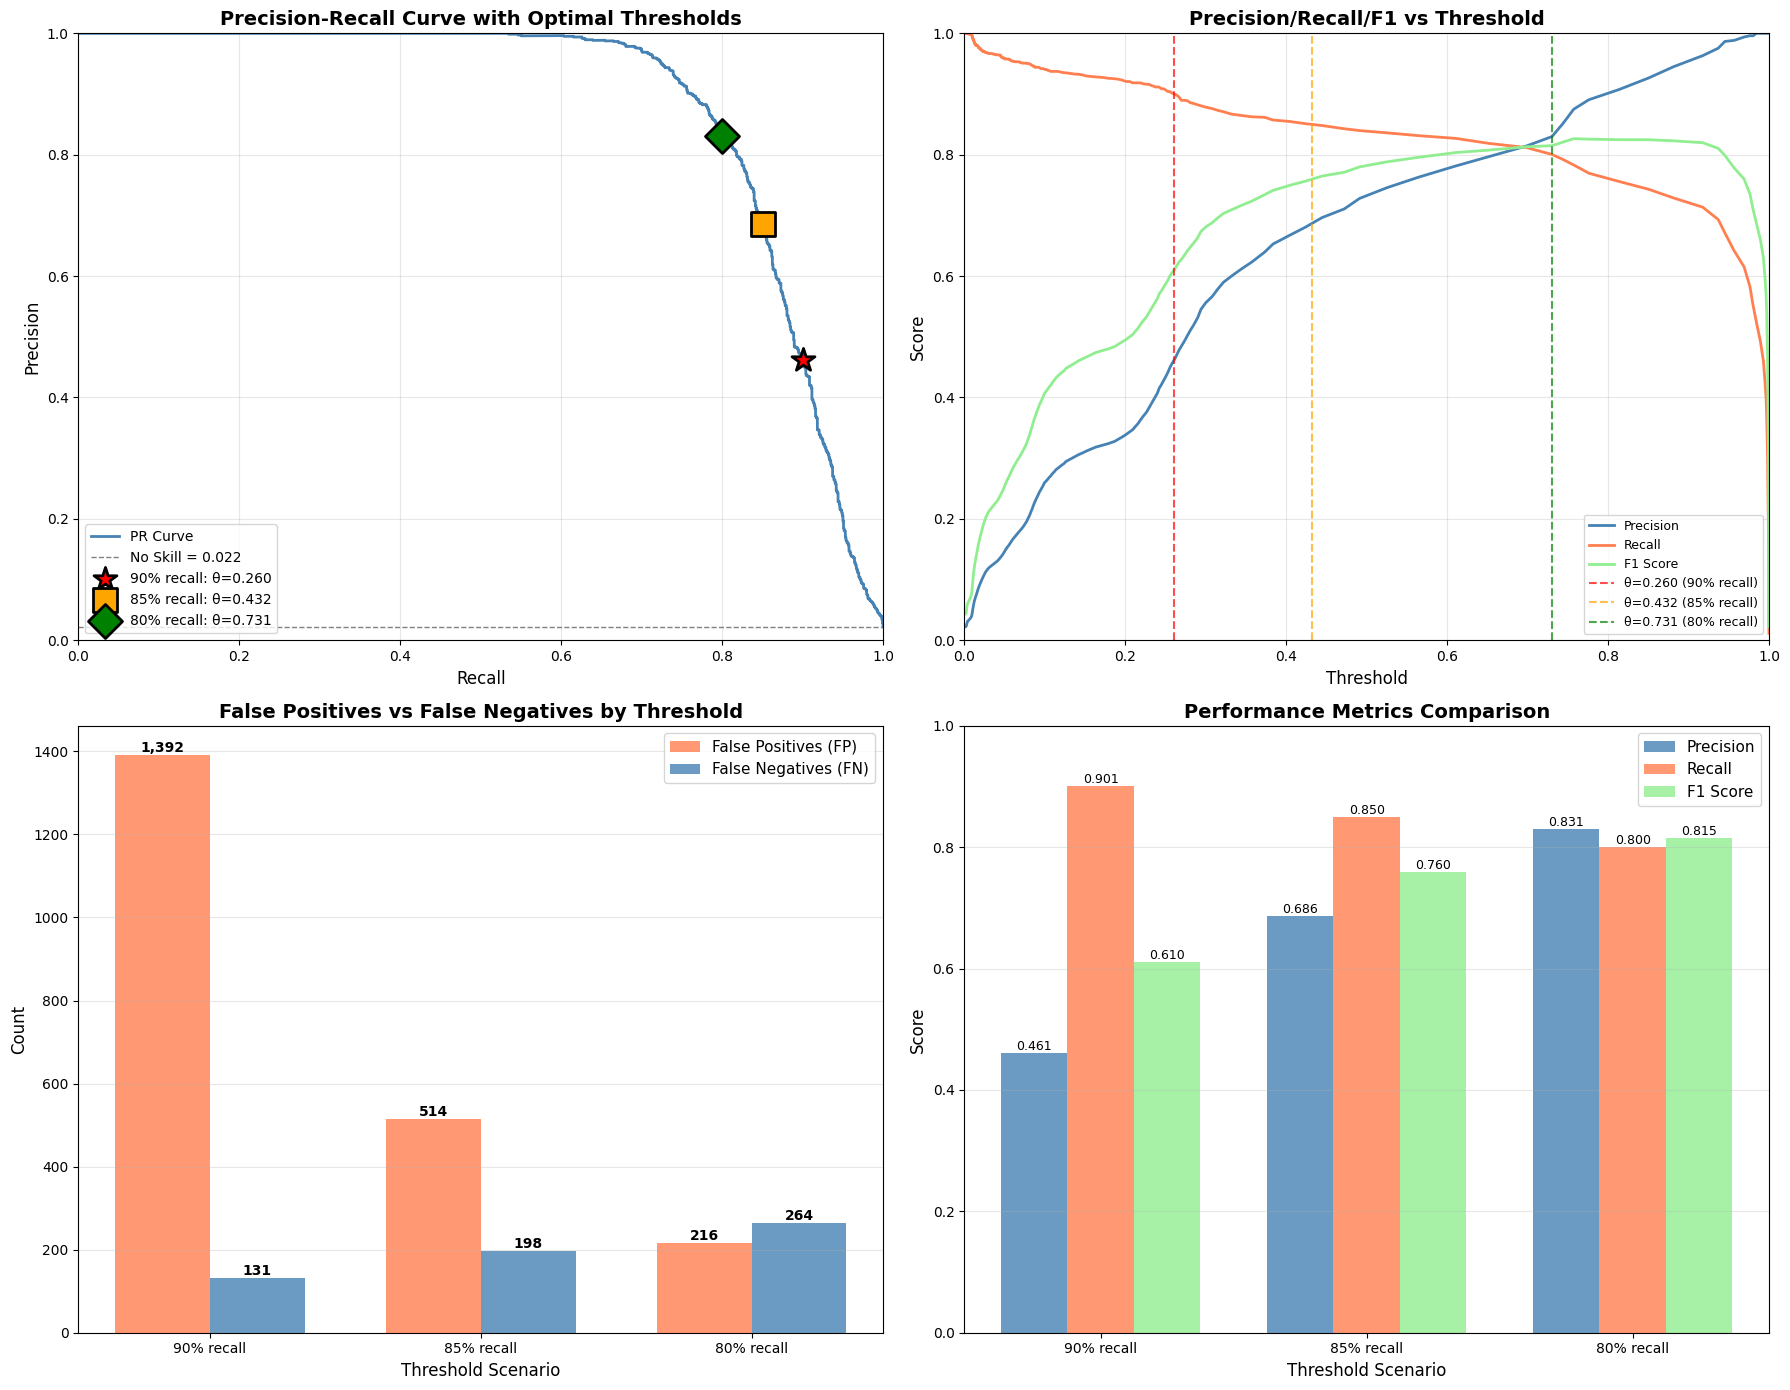

✓ Threshold optimization visualizations complete


In [64]:
# Visualize threshold optimization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Precision-Recall Curve with marked thresholds
ax = axes[0, 0]
ax.plot(recalls, precisions, color='steelblue', lw=2, label='PR Curve')
ax.axhline(y=y_val.mean(), color='gray', linestyle='--', lw=1, label=f'No Skill = {y_val.mean():.3f}')

# Mark optimal thresholds
colors = ['red', 'orange', 'green']
markers = ['*', 's', 'D']
for i, result in enumerate(threshold_results):
    ax.scatter(result['recall'], result['precision'], 
              c=colors[i], s=300, marker=markers[i], 
              edgecolors='black', linewidths=2,
              label=f"{result['target_recall']*100:.0f}% recall: θ={result['threshold']:.3f}", zorder=10)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve with Optimal Thresholds', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Plot 2: Precision/Recall/F1 vs Threshold
ax = axes[0, 1]

# Sample thresholds for clarity
step = max(1, len(thresholds) // 1000)
ax.plot(thresholds[::step], precisions[:-1][::step], 'steelblue', lw=2, label='Precision')
ax.plot(thresholds[::step], recalls[:-1][::step], 'coral', lw=2, label='Recall')

# Calculate F1 for all thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
ax.plot(thresholds[::step], f1_scores[::step], 'lightgreen', lw=2, label='F1 Score')

# Mark optimal thresholds
for i, result in enumerate(threshold_results):
    ax.axvline(x=result['threshold'], color=colors[i], linestyle='--', lw=1.5, 
              label=f"θ={result['threshold']:.3f} ({result['target_recall']*100:.0f}% recall)", alpha=0.7)

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision/Recall/F1 vs Threshold', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Plot 3: False Positives vs False Negatives
ax = axes[1, 0]

x = np.arange(len(threshold_results))
width = 0.35

fp_counts = [r['fp'] for r in threshold_results]
fn_counts = [r['fn'] for r in threshold_results]

bars1 = ax.bar(x - width/2, fp_counts, width, label='False Positives (FP)', color='coral', alpha=0.8)
bars2 = ax.bar(x + width/2, fn_counts, width, label='False Negatives (FN)', color='steelblue', alpha=0.8)

ax.set_xlabel('Threshold Scenario', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('False Positives vs False Negatives by Threshold', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['target_recall']*100:.0f}% recall" for r in threshold_results])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Metrics Comparison
ax = axes[1, 1]

metrics_data = pd.DataFrame([
    {
        'Scenario': f"{r['target_recall']*100:.0f}% recall",
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1']
    }
    for r in threshold_results
])

x = np.arange(len(metrics_data))
width = 0.25

bars1 = ax.bar(x - width, metrics_data['Precision'], width, label='Precision', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, metrics_data['Recall'], width, label='Recall', color='coral', alpha=0.8)
bars3 = ax.bar(x + width, metrics_data['F1'], width, label='F1 Score', color='lightgreen', alpha=0.8)

ax.set_xlabel('Threshold Scenario', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Scenario'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Threshold optimization visualizations complete")

In [67]:
# Create models directory if it doesn't exist
model_dir_path = Path(model_dir)
model_dir_path.mkdir(parents=True, exist_ok=True)

# 1. Save the final retrained model pipeline
model_path = model_dir_path / "xgb_fraud_detector.joblib"
joblib.dump(final_xgb_pipeline, model_path)
print(f"✓ Final retrained model saved to: {model_path}")
print(f"  File size: {model_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"  Training data: train+val combined ({len(X_train_val):,} samples)")

# 2. Save threshold configuration
threshold_config = {
    'default_threshold': 0.5,
    'optimized_thresholds': {
        'conservative_90pct_recall': {
            'threshold': float(threshold_results[0]['threshold']),
            'target_recall': 0.90,
            'achieved_recall': float(threshold_results[0]['recall']),
            'precision': float(threshold_results[0]['precision']),
            'f1': float(threshold_results[0]['f1']),
            'description': 'Catch most fraud (90% recall), accept more false positives'
        },
        'balanced_85pct_recall': {
            'threshold': float(threshold_results[1]['threshold']),
            'target_recall': 0.85,
            'achieved_recall': float(threshold_results[1]['recall']),
            'precision': float(threshold_results[1]['precision']),
            'f1': float(threshold_results[1]['f1']),
            'description': 'Balanced precision-recall trade-off (similar to default)'
        },
        'aggressive_80pct_recall': {
            'threshold': float(threshold_results[2]['threshold']),
            'target_recall': 0.80,
            'achieved_recall': float(threshold_results[2]['recall']),
            'precision': float(threshold_results[2]['precision']),
            'f1': float(threshold_results[2]['f1']),
            'description': 'Prioritize precision (80% recall), reduce false positives'
        }
    },
    'note': 'Thresholds optimized on validation set using final retrained model'
}

threshold_config_path = model_dir_path / "threshold_config.json"
with open(threshold_config_path, 'w') as f:
    json.dump(threshold_config, f, indent=2)
print(f"✓ Threshold configuration saved to: {threshold_config_path}")

# 3. Save feature lists
feature_lists = {
    'continuous_numeric': continuous_numeric,
    'categorical': categorical,
    'binary': binary,
    'all_features': continuous_numeric + categorical + binary
}

feature_lists_path = model_dir_path / "feature_lists.json"
with open(feature_lists_path, 'w') as f:
    json.dump(feature_lists, f, indent=2)
print(f"✓ Feature lists saved to: {feature_lists_path}")

print("\n" + "=" * 100)
print("MODEL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 100)

✓ Final retrained model saved to: models/xgb_fraud_detector.joblib
  File size: 0.14 MB
  Training data: train+val combined (239,756 samples)
✓ Threshold configuration saved to: models/threshold_config.json
✓ Feature lists saved to: models/feature_lists.json

MODEL ARTIFACTS SAVED SUCCESSFULLY
